# 04 - Exploratory Data Analysis

## Project: ECOMMERCE-AI-PLATFORM

This notebook performs exploratory data analysis on the cleaned Olist e-commerce datasets.

### Objectives

- Understand the structure of the cleaned datasets
- Analyze order trends over time
- Analyze sales and revenue performance
- Understand customer behavior
- Analyze payment methods
- Analyze product categories
- Analyze customer review scores
- Analyze seller performance
- Identify important business insights

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
PROJECT_ROOT = r"C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM"

DATA_DIR = os.path.join(PROJECT_ROOT, "data")

PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")

print("Project paths configured successfully!")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")

Project paths configured successfully!
Processed data directory: C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\processed


In [3]:
if os.path.exists(PROCESSED_DATA_DIR):

    processed_files = os.listdir(PROCESSED_DATA_DIR)

    print("Files available in the processed data folder:\n")

    for file in processed_files:
        print(file)

else:

    print("Processed data folder not found!")

Files available in the processed data folder:

category_translation_cleaned.csv
customers_cleaned.csv
geolocation_cleaned.csv
orders_cleaned.csv
order_items_cleaned.csv
order_payments_cleaned.csv
order_reviews_cleaned.csv
products_cleaned.csv
sellers_cleaned.csv


## 2. Load Cleaned Datasets

The cleaned datasets created by `03_data_cleaning.ipynb` are loaded from the processed data directory.

The `_cleaned.csv` naming convention is used consistently.

In [7]:
customers = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "customers_cleaned.csv")
)

geolocation = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "geolocation_cleaned.csv")
)

order_items = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "order_items_cleaned.csv")
)

order_payments = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "order_payments_cleaned.csv")
)

order_reviews = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "order_reviews_cleaned.csv")
)

orders = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "orders_cleaned.csv")
)

products = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "products_cleaned.csv")
)

sellers = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "sellers_cleaned.csv")
)

category_translation = pd.read_csv(
    os.path.join(PROCESSED_DATA_DIR, "category_translation_cleaned.csv")
)

print("All cleaned datasets loaded successfully!")

All cleaned datasets loaded successfully!


In [8]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}

print("Dataset Summary")
print("-" * 70)

for name, dataframe in datasets.items():

    print(
        f"{name:<25} "
        f"Rows: {dataframe.shape[0]:>8,} | "
        f"Columns: {dataframe.shape[1]:>3}"
    )

Dataset Summary
----------------------------------------------------------------------
Customers                 Rows:   99,441 | Columns:   5
Geolocation               Rows:  738,332 | Columns:   5
Order Items               Rows:  112,650 | Columns:   7
Order Payments            Rows:  103,886 | Columns:   5
Order Reviews             Rows:   99,224 | Columns:   7
Orders                    Rows:   99,441 | Columns:  16
Products                  Rows:   32,951 | Columns:  10
Sellers                   Rows:    3,095 | Columns:   4
Category Translation      Rows:       71 | Columns:   2


## 3. Dataset Dimensions

This section examines the number of rows and columns in each dataset.

In [9]:
print("Dataset Dimensions")
print("-" * 60)

for name, dataframe in datasets.items():

    rows, columns = dataframe.shape

    print(f"{name:<25} Rows: {rows:,} | Columns: {columns}")

Dataset Dimensions
------------------------------------------------------------
Customers                 Rows: 99,441 | Columns: 5
Geolocation               Rows: 738,332 | Columns: 5
Order Items               Rows: 112,650 | Columns: 7
Order Payments            Rows: 103,886 | Columns: 5
Order Reviews             Rows: 99,224 | Columns: 7
Orders                    Rows: 99,441 | Columns: 16
Products                  Rows: 32,951 | Columns: 10
Sellers                   Rows: 3,095 | Columns: 4
Category Translation      Rows: 71 | Columns: 2


In [10]:
print("Orders Dataset Information")
print("-" * 60)

orders.info()

Orders Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99441 non-null  object
 5   order_delivered_carrier_date   99441 non-null  object
 6   order_delivered_customer_date  99441 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
 8   delivery_days                  99441 non-null  int64 
 9   estimated_delivery_days        99441 non-null  int64 
 10  delivery_delay_days            99441 non-null  int64 
 11  order_year                     

In [11]:
print("Order Items Dataset Information")
print("-" * 60)

order_items.info()

Order Items Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [12]:
print("Customers Dataset Information")
print("-" * 60)

customers.info()

Customers Dataset Information
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


## 4. Missing Value Analysis

Although the datasets have already been cleaned, exploratory analysis is performed to verify the final missing-value situation.

In [13]:
missing_values = {}

for name, dataframe in datasets.items():

    total_missing = dataframe.isnull().sum().sum()

    missing_values[name] = total_missing

missing_values_df = pd.DataFrame(
    list(missing_values.items()),
    columns=["Dataset", "Missing Values"]
)

missing_values_df

,Dataset,Missing Values
0,Customers,0
1,Geolocation,0
2,Order Items,0
3,Order Payments,0
4,Order Reviews,0
5,Orders,0
6,Products,0
7,Sellers,0
8,Category Translation,0


In [14]:
print("Missing Values by Dataset")
print("-" * 60)

for name, dataframe in datasets.items():

    missing_count = dataframe.isnull().sum().sum()

    print(f"{name:<25} {missing_count:,}")

Missing Values by Dataset
------------------------------------------------------------
Customers                 0
Geolocation               0
Order Items               0
Order Payments            0
Order Reviews             0
Orders                    0
Products                  0
Sellers                   0
Category Translation      0


## 5. Duplicate Record Analysis

This section checks whether duplicate records remain after data cleaning.

In [15]:
duplicate_summary = {}

for name, dataframe in datasets.items():

    duplicate_count = dataframe.duplicated().sum()

    duplicate_summary[name] = duplicate_count

duplicate_summary_df = pd.DataFrame(
    list(duplicate_summary.items()),
    columns=["Dataset", "Duplicate Rows"]
)

duplicate_summary_df

,Dataset,Duplicate Rows
0,Customers,0
1,Geolocation,0
2,Order Items,0
3,Order Payments,0
4,Order Reviews,0
5,Orders,0
6,Products,0
7,Sellers,0
8,Category Translation,0


## 6. Orders Analysis

The orders dataset is one of the most important datasets in the Olist data model.

This section analyzes:

- Order status
- Order volume over time
- Order delivery performance
- Order lifecycle

In [16]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_delivery_days,delivery_delay_days,order_year,order_month,order_quarter,order_weekday,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,15,-8,2017,10,4,Monday,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,19,-6,2018,7,3,Tuesday,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,26,-18,2018,8,3,Wednesday,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,26,-13,2017,11,4,Saturday,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,12,-10,2018,2,1,Tuesday,On Time


In [17]:
print("Order Status Distribution")
print("-" * 60)

order_status_counts = orders["order_status"].value_counts()

order_status_counts

Order Status Distribution
------------------------------------------------------------


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

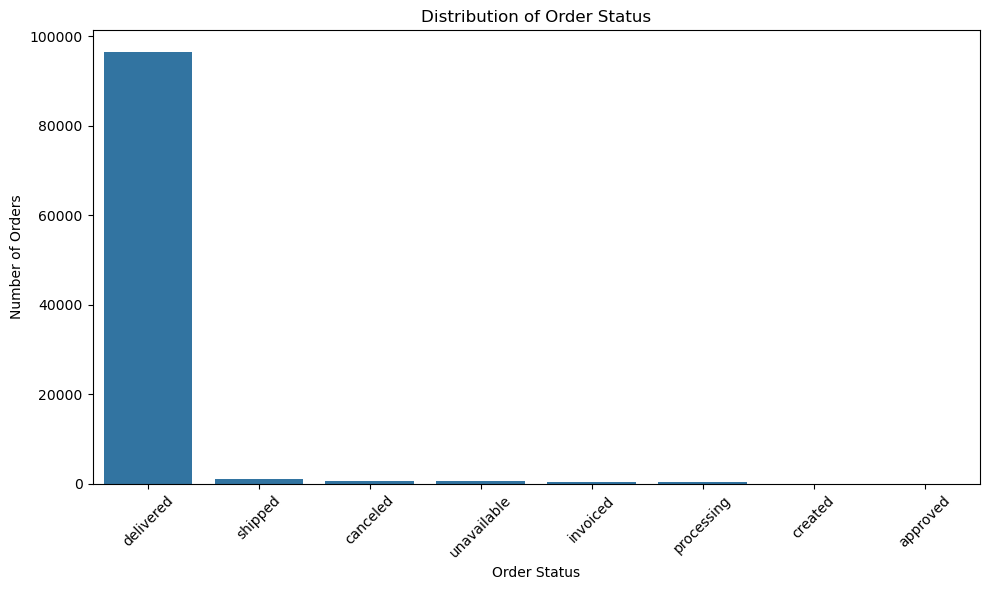

In [18]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [19]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year

orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month

orders["purchase_month_name"] = orders[
    "order_purchase_timestamp"
].dt.month_name()

orders["purchase_day"] = orders[
    "order_purchase_timestamp"
].dt.day

orders["purchase_weekday"] = orders[
    "order_purchase_timestamp"
].dt.day_name()

orders["purchase_date"] = orders[
    "order_purchase_timestamp"
].dt.date

print("Date-based order features created successfully!")

Date-based order features created successfully!


In [20]:
monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

monthly_orders.head()

order_purchase_timestamp
2016-09-30      4
2016-10-31    324
2016-11-30      0
2016-12-31      1
2017-01-31    800
Freq: ME, dtype: int64

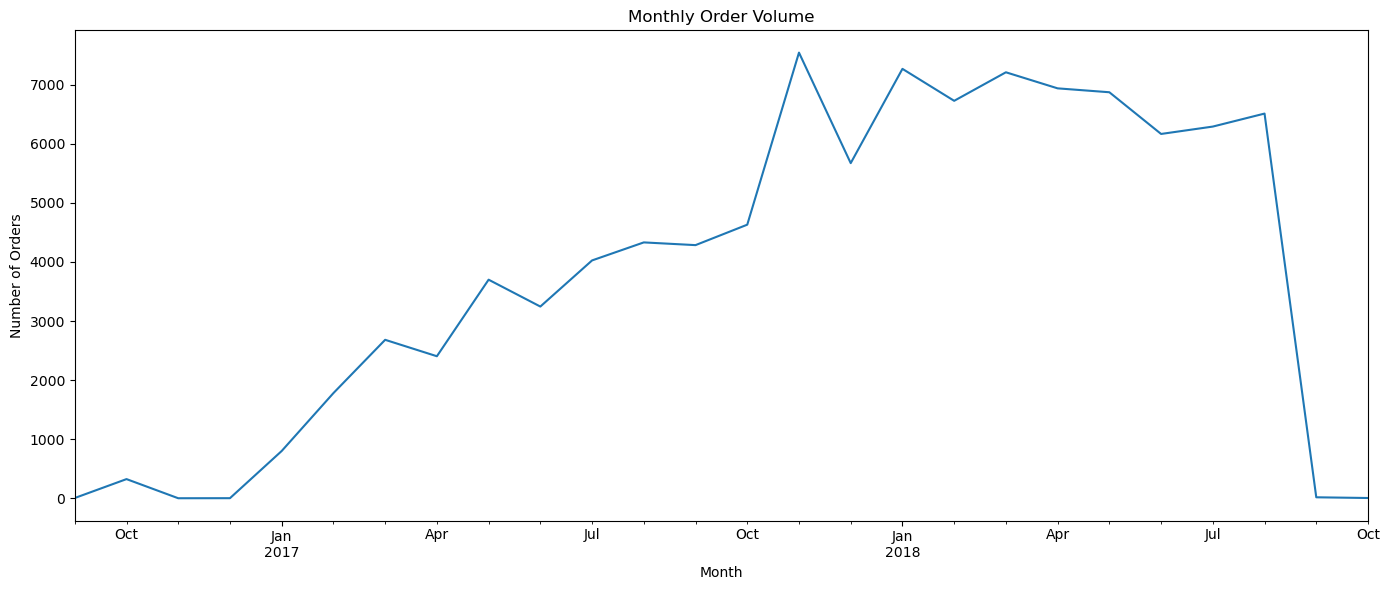

In [21]:
plt.figure(figsize=(14, 6))

monthly_orders.plot()

plt.title("Monthly Order Volume")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [22]:
weekday_orders = (
    orders["purchase_weekday"]
    .value_counts()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_orders = weekday_orders.reindex(weekday_order)

weekday_orders

purchase_weekday
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64

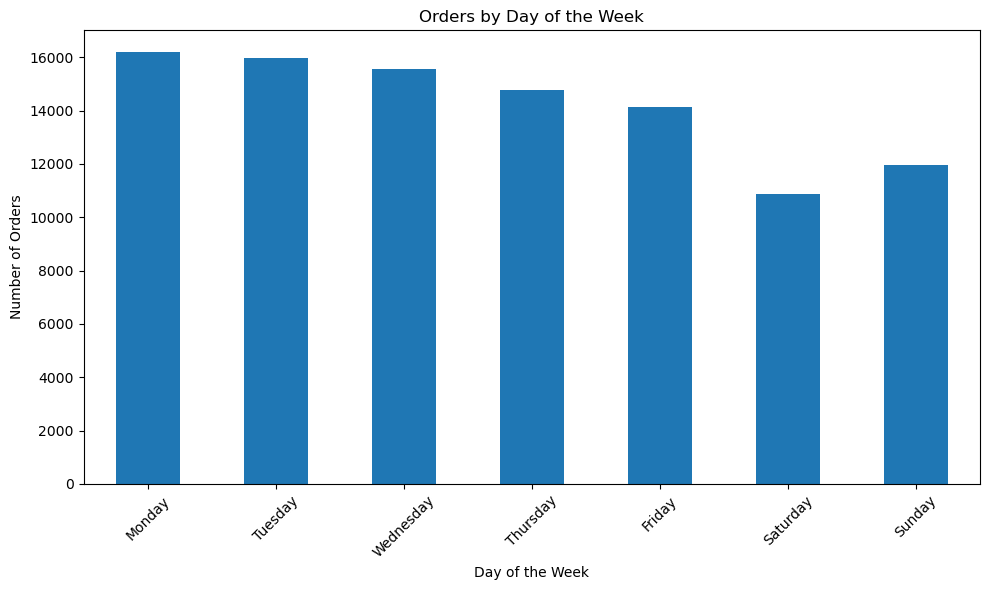

In [23]:
plt.figure(figsize=(10, 6))

weekday_orders.plot(kind="bar")

plt.title("Orders by Day of the Week")

plt.xlabel("Day of the Week")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 7. Order Delivery Analysis

The cleaned orders dataset contains delivery-related information.

This section analyzes:

- Estimated delivery dates
- Actual delivery dates
- Delivery duration
- Delivery delays

In [24]:
date_columns = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:

    if column in orders.columns:

        orders[column] = pd.to_datetime(
            orders[column],
            errors="coerce"
        )

print("Order date columns converted successfully!")

Order date columns converted successfully!


In [25]:
if (
    "order_purchase_timestamp" in orders.columns
    and "order_delivered_customer_date" in orders.columns
):

    orders["delivery_days"] = (
        orders["order_delivered_customer_date"]
        - orders["order_purchase_timestamp"]
    ).dt.total_seconds() / (24 * 60 * 60)

else:

    orders["delivery_days"] = np.nan

print("Delivery duration calculated successfully!")

Delivery duration calculated successfully!


In [26]:
if (
    "order_delivered_customer_date" in orders.columns
    and "order_estimated_delivery_date" in orders.columns
):

    orders["delivery_delay_days"] = (
        orders["order_delivered_customer_date"]
        - orders["order_estimated_delivery_date"]
    ).dt.total_seconds() / (24 * 60 * 60)

else:

    orders["delivery_delay_days"] = np.nan

print("Delivery delay calculated successfully!")

Delivery delay calculated successfully!


In [27]:
orders[
    [
        "order_id",
        "delivery_days",
        "delivery_delay_days"
    ]
].head()

,order_id,delivery_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,-5.355729
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,-17.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,-12.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,-9.238171


In [28]:
print("Delivery Days Summary")

orders["delivery_days"].describe()

Delivery Days Summary


count    99441.000000
mean        12.921854
std          9.807313
min          0.533414
25%          6.866806
50%         10.447870
75%         16.198403
max        209.628611
Name: delivery_days, dtype: float64

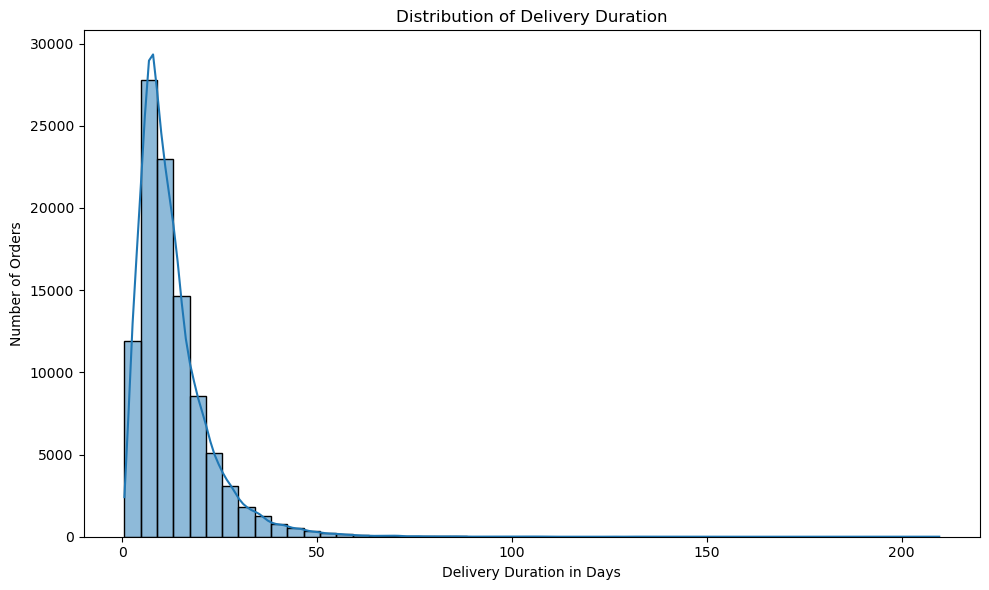

In [29]:
plt.figure(figsize=(10, 6))

sns.histplot(
    orders["delivery_days"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Delivery Duration")

plt.xlabel("Delivery Duration in Days")

plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

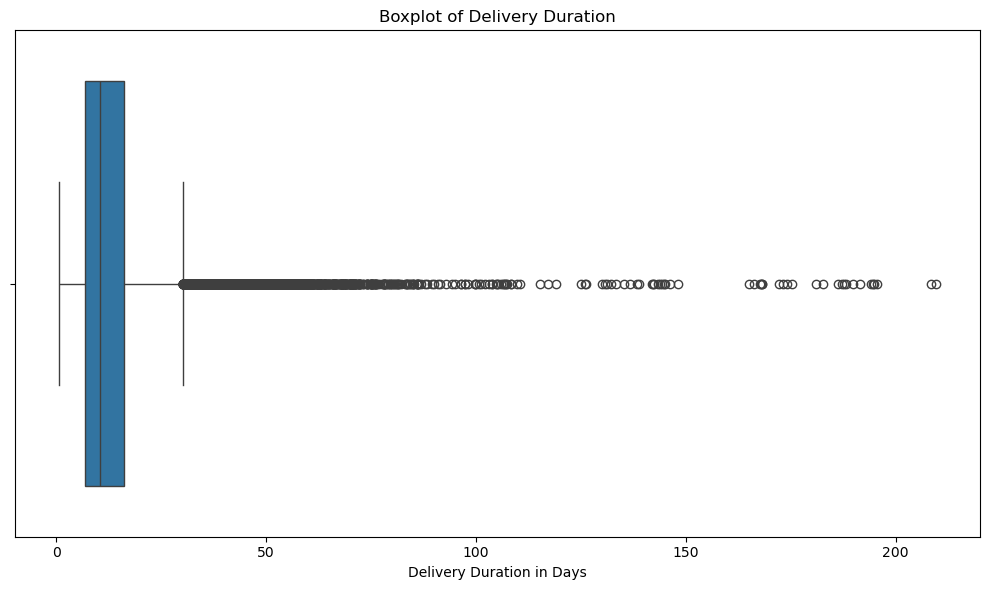

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=orders["delivery_days"]
)

plt.title("Boxplot of Delivery Duration")

plt.xlabel("Delivery Duration in Days")

plt.tight_layout()

plt.show()

## 8. Order Items and Revenue Analysis

The order items dataset contains product-level transaction information.

This section analyzes:

- Product prices
- Freight values
- Total revenue
- Top-selling products
- Seller activity

In [31]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [32]:
order_items["item_total_value"] = (
    order_items["price"]
    + order_items["freight_value"]
)

print("Item-level total value calculated successfully!")

Item-level total value calculated successfully!


In [33]:
print("Price Statistics")

order_items["price"].describe()

Price Statistics


count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [34]:
print("Freight Value Statistics")

order_items["freight_value"].describe()

Freight Value Statistics


count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [35]:
print("Total Item Value Statistics")

order_items["item_total_value"].describe()

Total Item Value Statistics


count    112650.000000
mean        140.644059
std         190.724394
min           6.080000
25%          55.220000
50%          92.320000
75%         157.937500
max        6929.310000
Name: item_total_value, dtype: float64

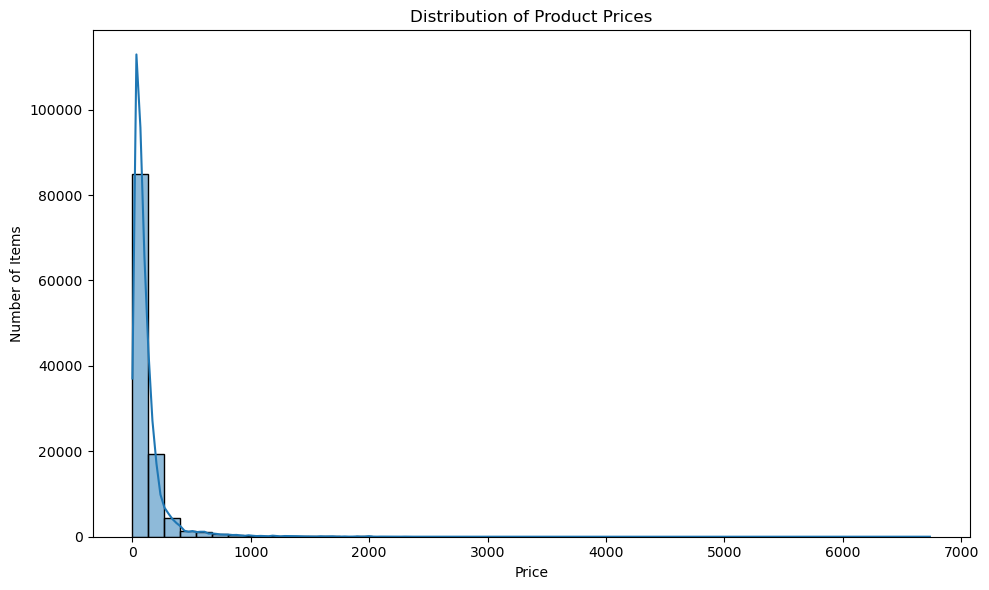

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    order_items["price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Product Prices")

plt.xlabel("Price")

plt.ylabel("Number of Items")

plt.tight_layout()

plt.show()

In [37]:
top_products = (
    order_items
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
dtype: int64

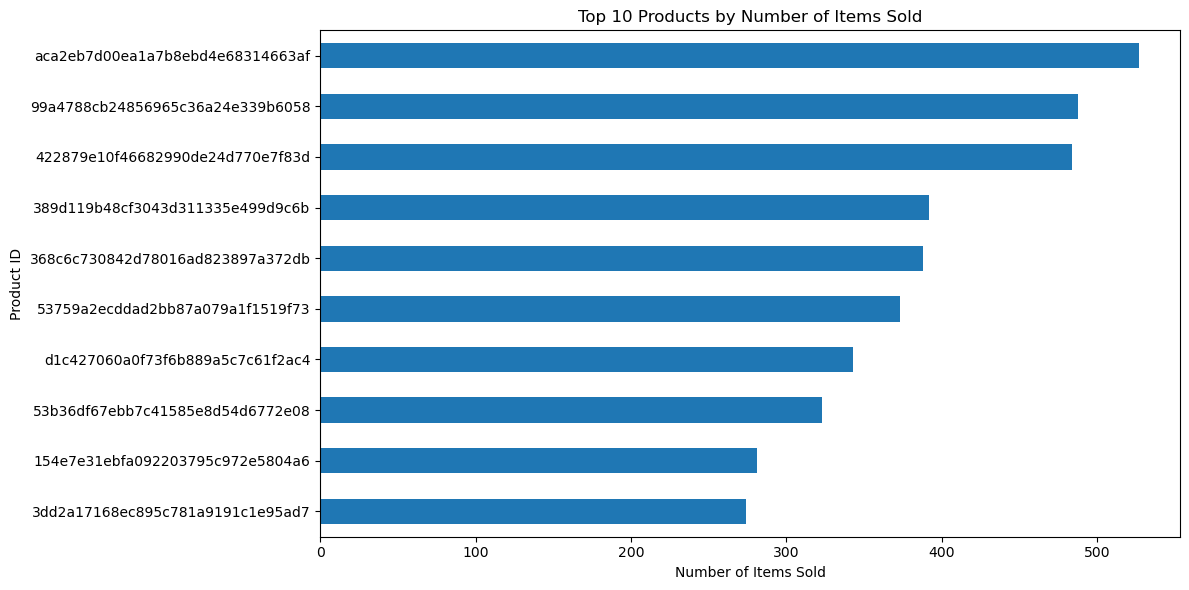

In [38]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Number of Items Sold")

plt.xlabel("Number of Items Sold")

plt.ylabel("Product ID")

plt.tight_layout()

plt.show()

In [39]:
top_sellers = (
    order_items
    .groupby("seller_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_sellers

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
dtype: int64

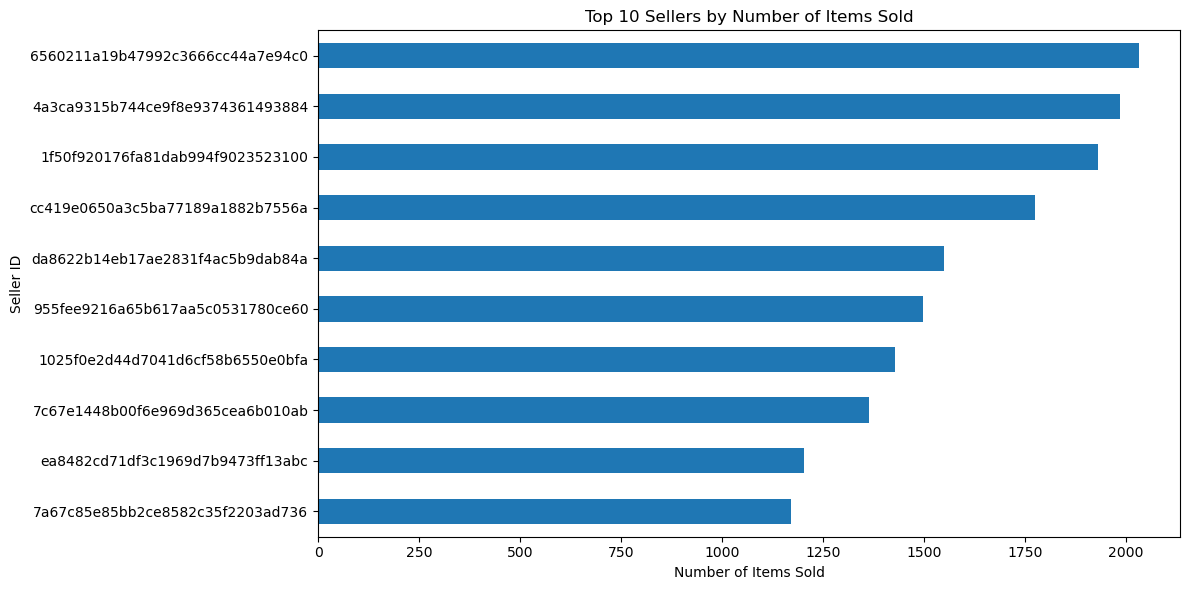

In [40]:
plt.figure(figsize=(12, 6))

top_sellers.sort_values().plot(kind="barh")

plt.title("Top 10 Sellers by Number of Items Sold")

plt.xlabel("Number of Items Sold")

plt.ylabel("Seller ID")

plt.tight_layout()

plt.show()

## 9. Payment Analysis

This section analyzes customer payment behavior.

The analysis includes:

- Payment methods
- Payment installments
- Payment values

In [41]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [42]:
payment_type_counts = (
    order_payments["payment_type"]
    .value_counts()
)

payment_type_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

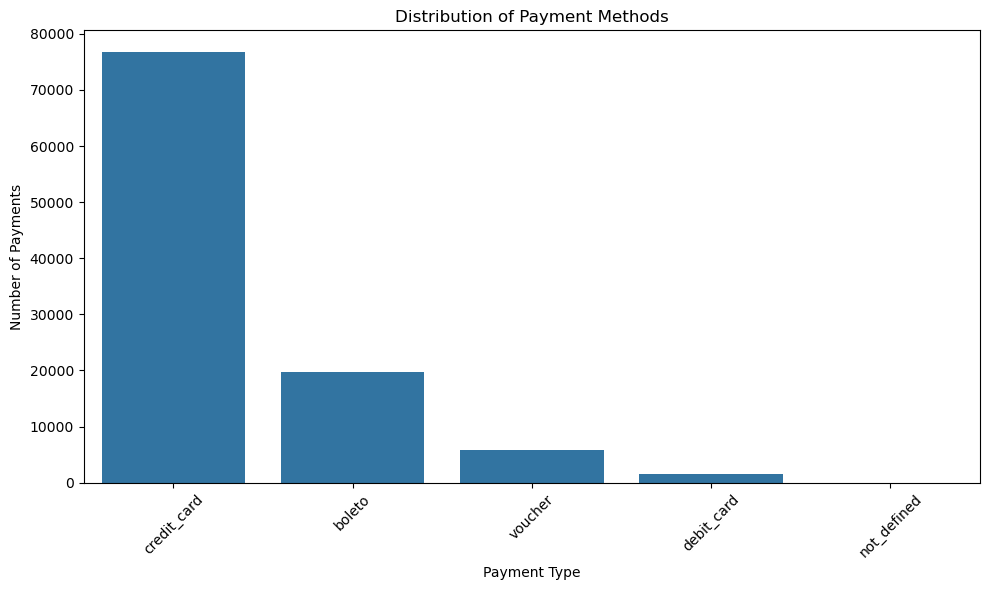

In [43]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=order_payments,
    x="payment_type",
    order=payment_type_counts.index
)

plt.title("Distribution of Payment Methods")

plt.xlabel("Payment Type")

plt.ylabel("Number of Payments")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

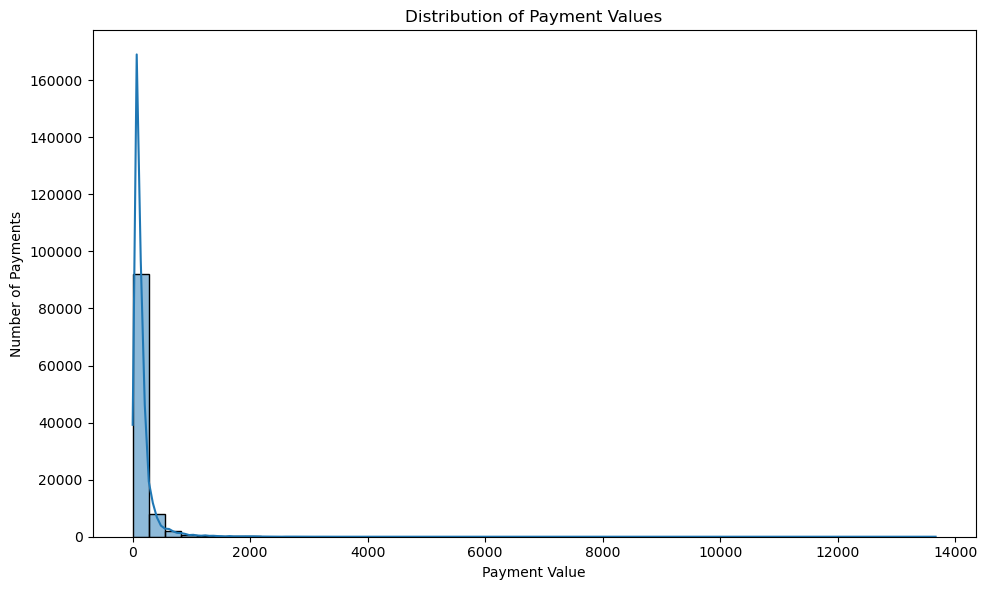

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(
    order_payments["payment_value"],
    bins=50,
    kde=True
)

plt.title("Distribution of Payment Values")

plt.xlabel("Payment Value")

plt.ylabel("Number of Payments")

plt.tight_layout()

plt.show()

In [45]:
installment_counts = (
    order_payments["payment_installments"]
    .value_counts()
    .sort_index()
)

installment_counts.head(20)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
Name: count, dtype: int64

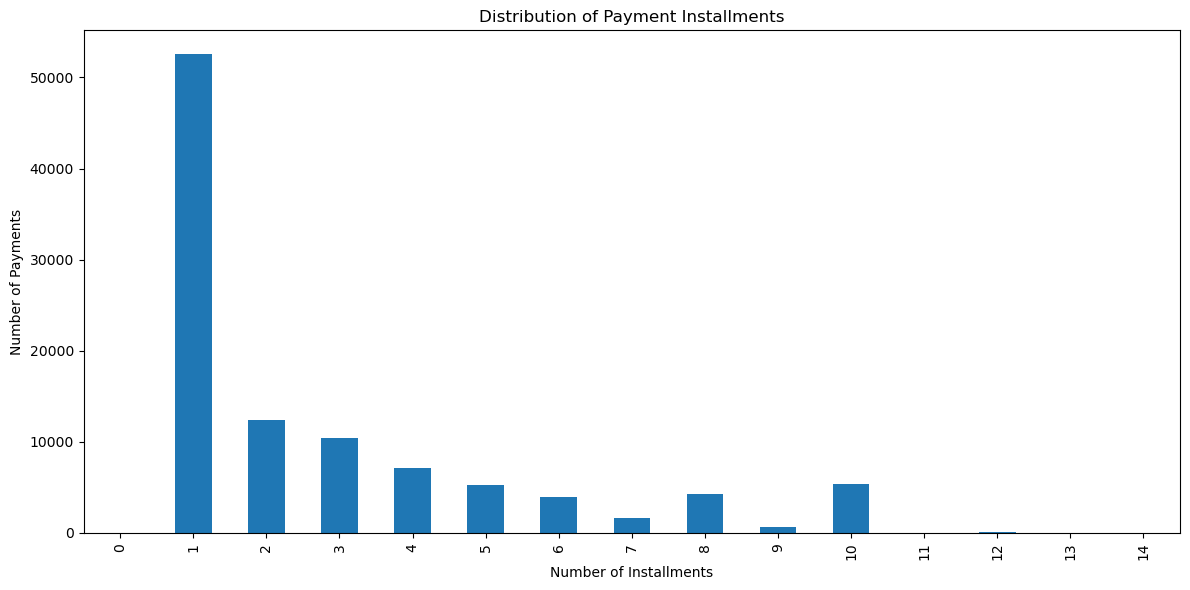

In [46]:
plt.figure(figsize=(12, 6))

installment_counts.head(15).plot(kind="bar")

plt.title("Distribution of Payment Installments")

plt.xlabel("Number of Installments")

plt.ylabel("Number of Payments")

plt.tight_layout()

plt.show()

## 10. Customer Review Analysis

Customer reviews are important for understanding customer satisfaction.

This section analyzes:

- Review score distribution
- Review comments
- Relationship between reviews and delivery performance

In [47]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comment,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comment,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comment,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [48]:
review_score_counts = (
    order_reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_score_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

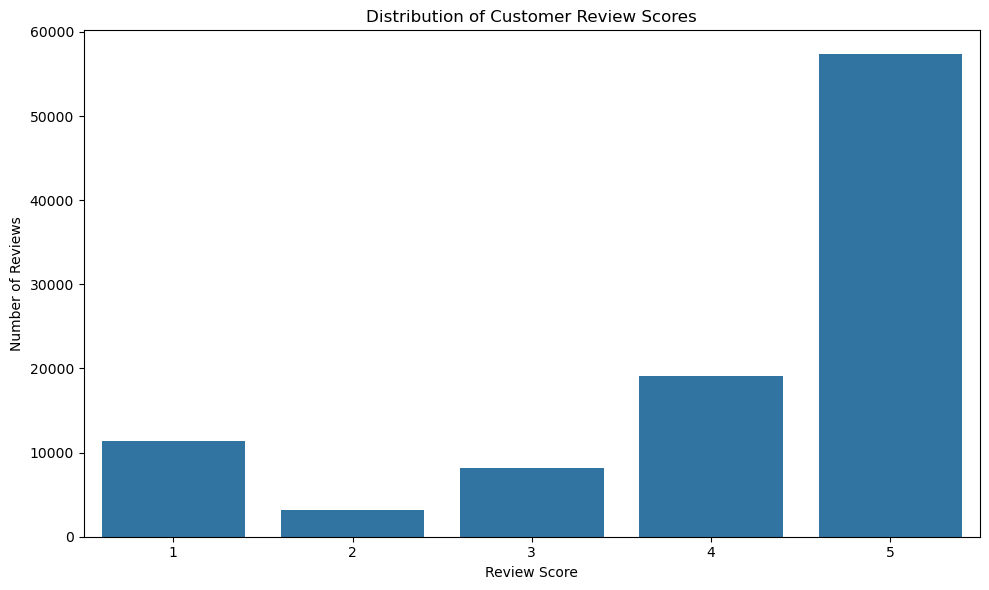

In [49]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=order_reviews,
    x="review_score",
    order=sorted(order_reviews["review_score"].dropna().unique())
)

plt.title("Distribution of Customer Review Scores")

plt.xlabel("Review Score")

plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.show()

In [50]:
average_review_score = order_reviews["review_score"].mean()

print(
    f"Average Customer Review Score: "
    f"{average_review_score:.2f}"
)

Average Customer Review Score: 4.09


## 11. Product Category Analysis

This section analyzes the distribution of products across product categories.

In [51]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [52]:
category_counts = (
    products["product_category_name"]
    .value_counts()
    .head(20)
)

category_counts

product_category_name
cama_mesa_banho                      3029
esporte_lazer                        2867
moveis_decoracao                     2657
beleza_saude                         2444
utilidades_domesticas                2335
automotivo                           1900
informatica_acessorios               1639
brinquedos                           1411
relogios_presentes                   1329
telefonia                            1134
bebes                                 919
perfumaria                            868
fashion_bolsas_e_acessorios           849
papelaria                             849
cool_stuff                            789
ferramentas_jardim                    753
pet_shop                              719
unknown                               610
eletronicos                           517
construcao_ferramentas_construcao     400
Name: count, dtype: int64

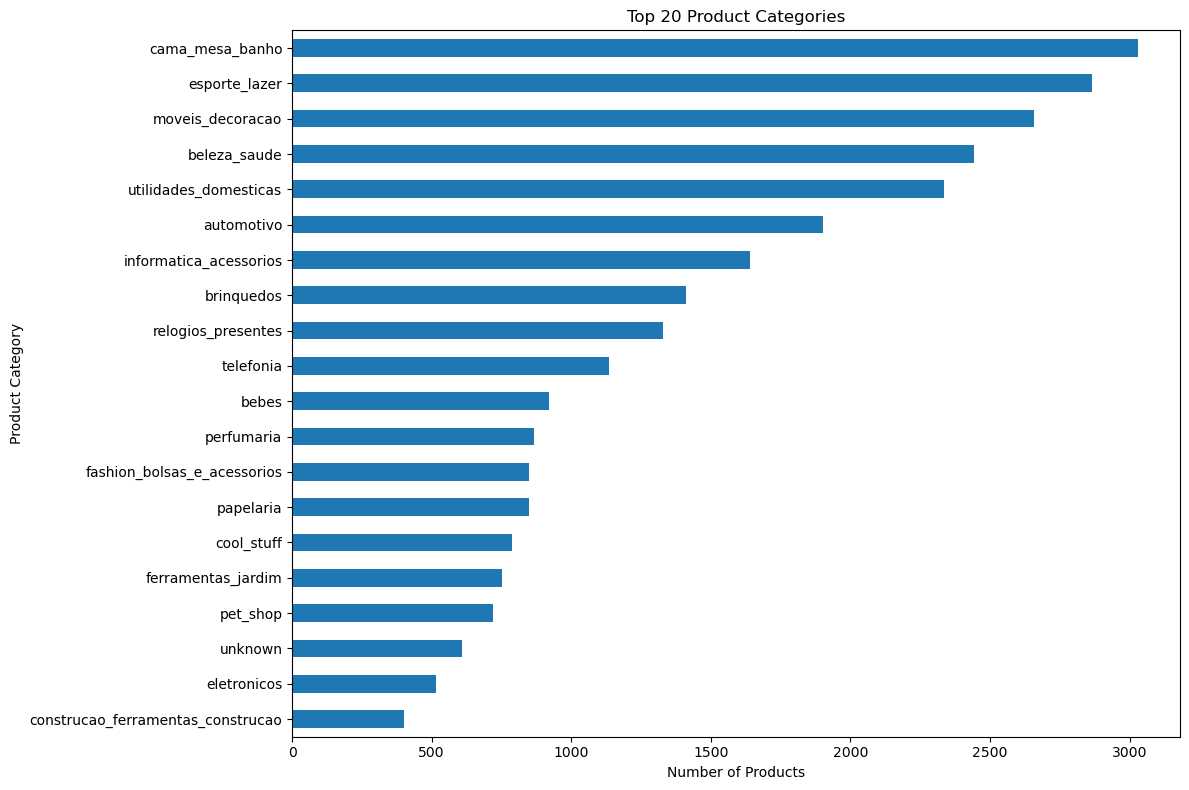

In [53]:
plt.figure(figsize=(12, 8))

category_counts.sort_values().plot(kind="barh")

plt.title("Top 20 Product Categories")

plt.xlabel("Number of Products")

plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

## 12. Seller Analysis

This section analyzes seller distribution and seller locations.

In [54]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [55]:
seller_state_counts = (
    sellers["seller_state"]
    .value_counts()
    .head(15)
)

seller_state_counts

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
Name: count, dtype: int64

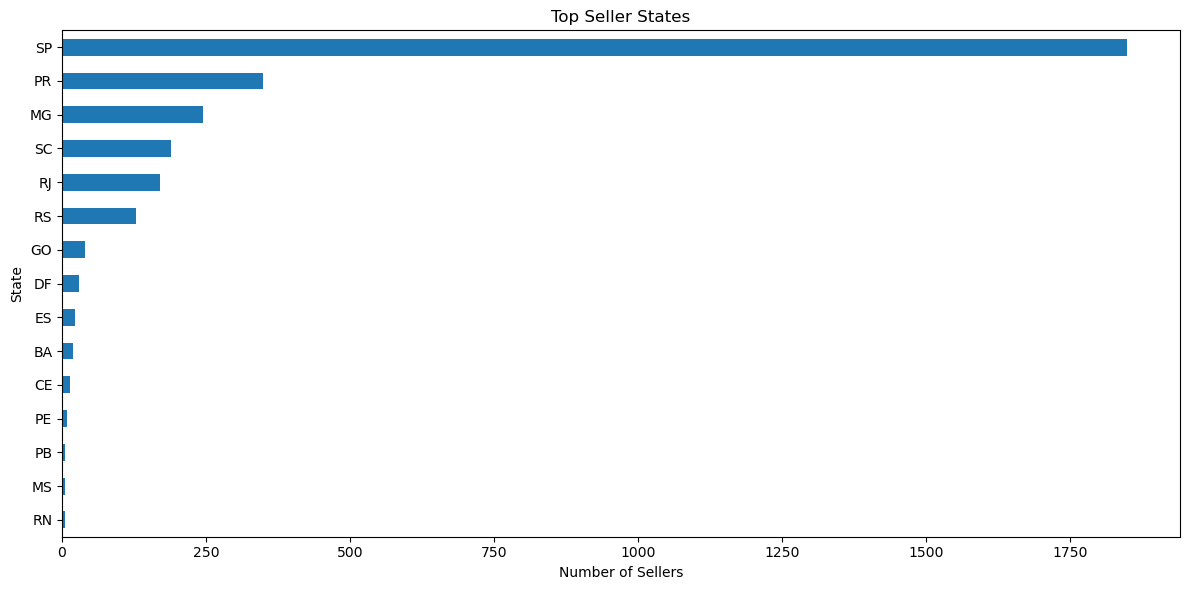

In [56]:
plt.figure(figsize=(12, 6))

seller_state_counts.sort_values().plot(kind="barh")

plt.title("Top Seller States")

plt.xlabel("Number of Sellers")

plt.ylabel("State")

plt.tight_layout()

plt.show()

## 13. Customer Geographic Analysis

This section examines the geographic distribution of customers.

In [57]:
customer_state_counts = (
    customers["customer_state"]
    .value_counts()
    .head(15)
)

customer_state_counts

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
Name: count, dtype: int64

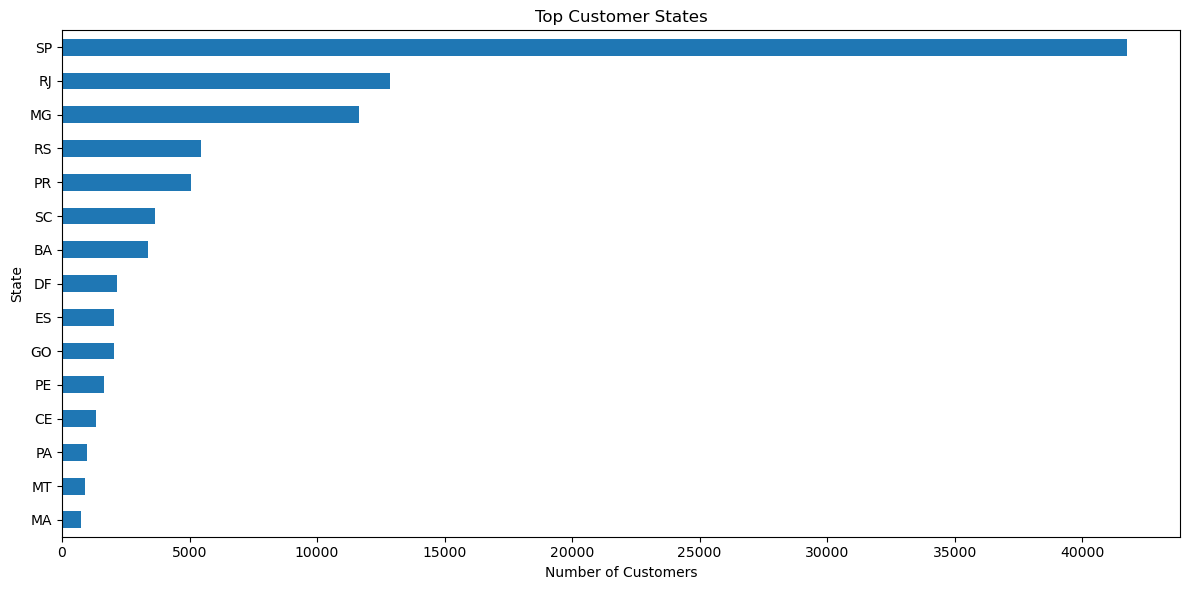

In [58]:
plt.figure(figsize=(12, 6))

customer_state_counts.sort_values().plot(kind="barh")

plt.title("Top Customer States")

plt.xlabel("Number of Customers")

plt.ylabel("State")

plt.tight_layout()

plt.show()

## 14. Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

This analysis is useful for future:

- Sales analytics
- Customer segmentation
- Customer lifetime value analysis
- Predictive modeling

In [59]:
numeric_columns = order_items.select_dtypes(
    include=np.number
).columns

order_items_correlation = order_items[
    numeric_columns
].corr()

order_items_correlation

,order_item_id,price,freight_value,item_total_value
order_item_id,1.000000,-0.060522,-0.029380,-0.060707
price,-0.060522,1.000000,0.414204,0.997151
freight_value,-0.029380,0.414204,1.000000,0.481681
item_total_value,-0.060707,0.997151,0.481681,1.000000


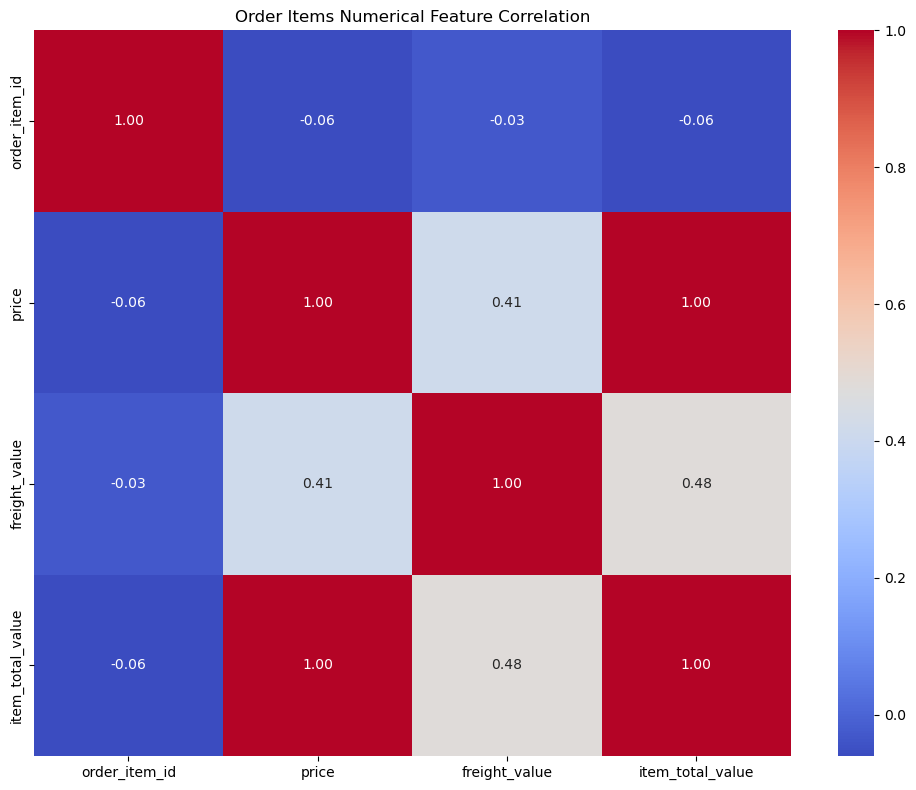

In [60]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    order_items_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Order Items Numerical Feature Correlation")

plt.tight_layout()

plt.show()

In [61]:
print("Exploratory Data Analysis completed successfully!")

Exploratory Data Analysis completed successfully!
